In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [21]:
df=pd.read_csv('cleanenddata1.csv',index_col=0)
df.head()

,brands,code,product_name,energy_kcal_value,energy_kj_value,carbohydrates_value,sugars_value,fat_value,saturated_fat_value,proteins_value,salt_value,sodium_value,nova_group,nutrition_score_fr,fruits_vegetables_nuts_estimate_from_ingredients_100g
0,sidi ali,6111035000430,sidi ali,0.0,20.0,42.0,14.0,0.0,0.00,0.0,0.00000,0.000000,1.0,1.0,0.0
1,jaouda,6111242100992,perly,97.0,406.0,9.4,7.5,3.0,1.15,8.0,0.00000,0.000000,3.0,4.0,0.0
2,sidi ali,6111035002175,sidi ali,0.0,20.0,42.0,14.0,0.0,0.00,0.0,65.00000,26.000000,1.0,0.0,0.0
3,les eaux minrales doulmssidi ali,6111035000058,eau minrale naturelle,0.0,0.0,0.0,0.0,0.0,0.00,0.0,65.00000,26.000000,1.0,0.0,0.0
4,aquafina,6111252421568,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00508,0.002032,1.0,0.0,0.0


In [3]:
"""
Key Nutritional Indicators:
Feature--->Meaning--->Health Relevance
energy-kcal_value--->Calories per 100g--->High calories → obesity risk if consumed excessively
carbohydrates_value--->Total carbs per 100g--->Includes sugars + starches
sugars_value--->Sugar per 100g--->High sugar → diabetes, dental issues
sugar_to_carb_ratio--->Ratio of sugar to total carbs--->Higher ratio → more added sugars
fat_value, saturated-fat_value--->Total and saturated fats--->High saturated fat → heart risks
proteins_value--->Protein per 100g--->Beneficial nutrient
nova-group--->Food processing classification (1-4)--->1: Unprocessed → 4: Ultra-processed
nutrition-score-fr--->Healthiness score (lower = healthier)--->European Nutri-Score metric
calorie_category, sugar_category--->Derived labels (e.g. “Low”, “Medium”, “High”)--->Easier for grouping
is_ultra_processed--->Boolean (True if NOVA=4)--->Used to assess food processing risk
"""

'\nKey Nutritional Indicators:\nFeature--->Meaning--->Health Relevance\nenergy-kcal_value--->Calories per 100g--->High calories → obesity risk if consumed excessively\ncarbohydrates_value--->Total carbs per 100g--->Includes sugars + starches\nsugars_value--->Sugar per 100g--->High sugar → diabetes, dental issues\nsugar_to_carb_ratio--->Ratio of sugar to total carbs--->Higher ratio → more added sugars\nfat_value, saturated-fat_value--->Total and saturated fats--->High saturated fat → heart risks\nproteins_value--->Protein per 100g--->Beneficial nutrient\nnova-group--->Food processing classification (1-4)--->1: Unprocessed → 4: Ultra-processed\nnutrition-score-fr--->Healthiness score (lower = healthier)--->European Nutri-Score metric\ncalorie_category, sugar_category--->Derived labels (e.g. “Low”, “Medium”, “High”)--->Easier for grouping\nis_ultra_processed--->Boolean (True if NOVA=4)--->Used to assess food processing risk\n'

In [28]:

# 1️)sugar_to_carb_ratio
# # Safely calculate ratio, avoid division by zero
df['sugar_to_carb_ratio'] = df.apply(
    lambda row: row['sugars_value'] / row['carbohydrates_value']
    if pd.notnull(row['sugars_value']) and pd.notnull(row['carbohydrates_value']) and row['carbohydrates_value'] != 0
    else np.nan,
    axis=1
)

# 2️)calorie_category (energy-kcal_value)
# Example thresholds (per 100g)
def calorie_class(kcal):
    if pd.isnull(kcal):
        return np.nan
    elif kcal < 40:
        return 'Low'
    elif 40 <= kcal <= 100:
        return 'Moderate'
    else:
        return 'High'

df['calorie_category'] = df['energy_kcal_value'].apply(calorie_class)

# 3️)sugar_category (sugars_value)
def sugar_class(sugar):
    if pd.isnull(sugar):
        return np.nan
    elif sugar < 5:
        return 'Low Sugar'
    elif 5 <= sugar <= 22.5:
        return 'Moderate Sugar'
    else:
        return 'High Sugar'

df['sugar_category'] = df['sugars_value'].apply(sugar_class)

# 4️)is_ultra_processed (nova-group)
# Flag as 'Yes' if nova-group == 4, else 'No'
df['is_ultra_processed'] = df['nova_group'].apply(
    lambda x: 'Yes' if x == 4 else ('No' if pd.notnull(x) else np.nan)
)
df.head()

,brands,code,product_name,energy_kcal_value,energy_kj_value,carbohydrates_value,sugars_value,fat_value,saturated_fat_value,proteins_value,salt_value,sodium_value,nova_group,nutrition_score_fr,fruits_vegetables_nuts_estimate_from_ingredients_100g,sugar_to_carb_ratio,calorie_category,sugar_category,is_ultra_processed
0,sidi ali,6111035000430,sidi ali,0.0,20.0,42.0,14.0,0.0,0.00,0.0,0.00000,0.000000,1.0,1.0,0.0,0.333333,Low,Moderate Sugar,No
1,jaouda,6111242100992,perly,97.0,406.0,9.4,7.5,3.0,1.15,8.0,0.00000,0.000000,3.0,4.0,0.0,0.797872,Moderate,Moderate Sugar,No
2,sidi ali,6111035002175,sidi ali,0.0,20.0,42.0,14.0,0.0,0.00,0.0,65.00000,26.000000,1.0,0.0,0.0,0.333333,Low,Moderate Sugar,No
3,les eaux minrales doulmssidi ali,6111035000058,eau minrale naturelle,0.0,0.0,0.0,0.0,0.0,0.00,0.0,65.00000,26.000000,1.0,0.0,0.0,NaN,Low,Low Sugar,No
4,aquafina,6111252421568,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00508,0.002032,1.0,0.0,0.0,NaN,Low,Low Sugar,No


In [39]:
df.describe()

,code,energy_kcal_value,energy_kj_value,carbohydrates_value,sugars_value,fat_value,saturated_fat_value,proteins_value,salt_value,sodium_value,nova_group,nutrition_score_fr,fruits_vegetables_nuts_estimate_from_ingredients_100g,sugar_to_carb_ratio
count,1.125100e+04,11251.00000,11251.000000,11251.000000,11251.000000,11251.000000,11251.000000,11251.000000,11251.000000,11251.000000,11251.000000,11251.000000,11251.000000,10604.000000
mean,4.500208e+12,275.40213,1149.889953,28.173132,11.256287,14.426567,4.897903,6.833553,8.641565,3.456626,3.323616,9.004429,18.001176,0.526414
std,2.377922e+12,203.55430,848.318963,26.937166,17.375174,19.473902,8.644951,6.938409,183.010498,73.204199,1.004289,9.573203,30.486959,0.657564
min,1.816600e+04,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-15.000000,-0.066406,0.000000
25%,3.229821e+12,93.00000,389.112000,4.800000,1.000000,1.300000,0.300000,1.500000,0.050000,0.020000,3.000000,1.000000,0.000000,0.103112
50%,4.088600e+12,248.00000,1038.000000,15.000000,4.000000,6.500000,1.300000,5.500000,0.330000,0.132000,4.000000,7.000000,0.125000,0.472545
75%,6.111101e+12,431.00000,1807.000000,54.700000,13.000000,21.000000,5.700000,9.100000,0.982500,0.393000,4.000000,16.000000,21.225781,0.922877
max,9.557129e+12,947.50000,3963.994310,130.600000,395.000000,100.000000,94.500000,101.000000,12500.000000,5000.000000,4.000000,40.000000,197.200000,38.000000


Text(0.5, 1.0, 'Correlation Heatmap')

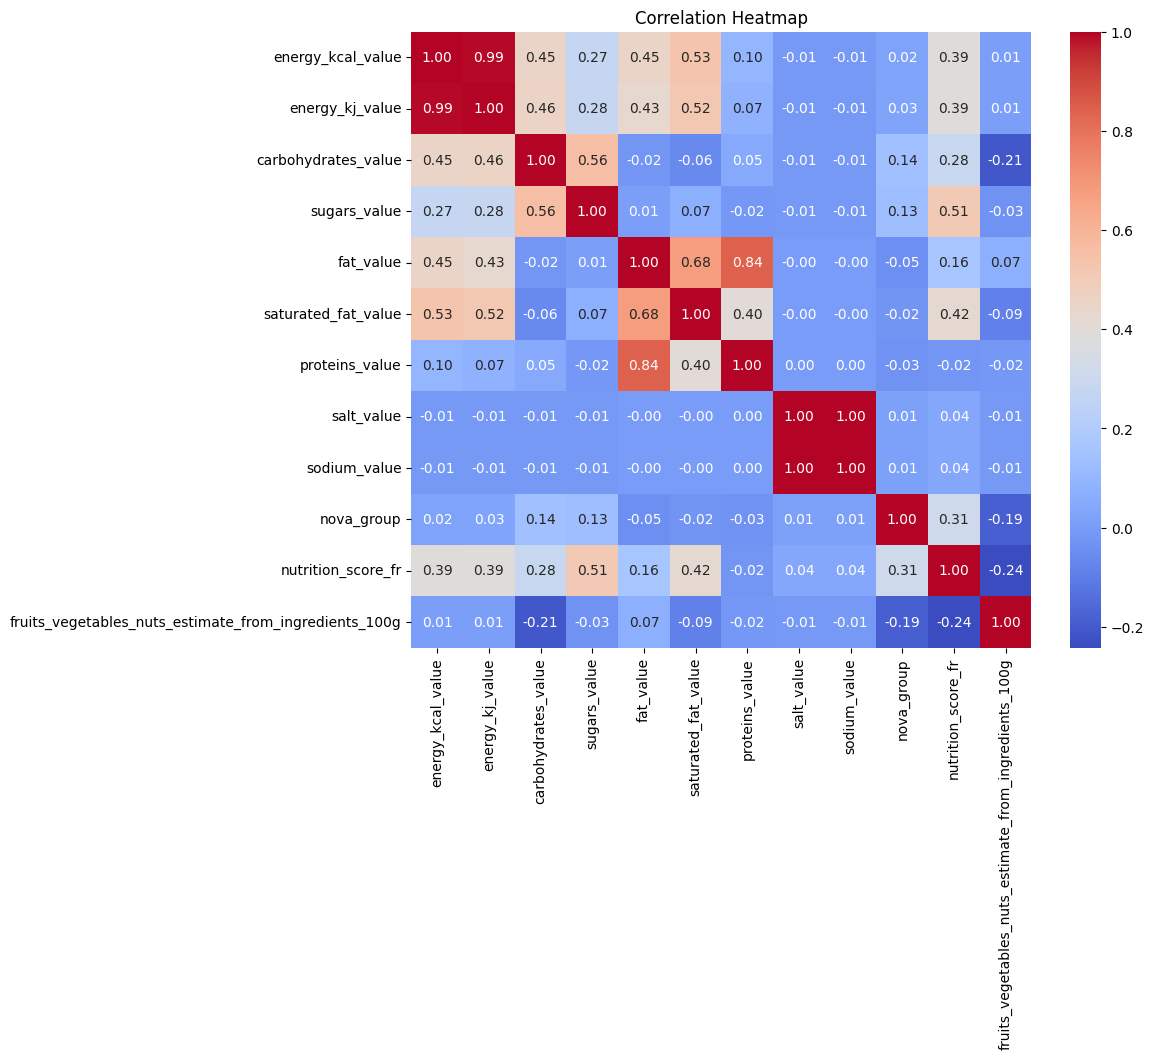

In [5]:
correlation_matrix=df.iloc[:,3:-4]
correlation_matrix=correlation_matrix.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap='coolwarm')
plt.title('Correlation Heatmap')

In [ ]:
'''
Strong Correlations:
fat_value & protien_value=0.84



Moderate Correlations:
Energy-kcal-value & carbohydrates_value = 0.45
Energy-kcal-value & fat_value = 0.45
Energy-kcal-value & saturated_fat_value = 0.53
Energy-kcal-value & nutrition_score_fr = 0.39
sugar_value & carbohydrates_value = 0.56
sugar_value & nutrition_score_fr = 0.51
fat_value & saturated_fat_value=0.68
saturated_fat_value & protien_value= 0.40
saturated_fat_value & nutrition_score_fr= 0.42
nova_group & nutrition_score_fr= 0.31

'''

In [6]:
nutrients_columns=['energy_kcal_value',
       'energy_kj_value', 'carbohydrates_value', 'sugars_value', 'fat_value',
       'saturated_fat_value', 'proteins_value', 'salt_value', 'sodium_value',
        'nutrition_score_fr',
       'fruits_vegetables_nuts_estimate_from_ingredients_100g']

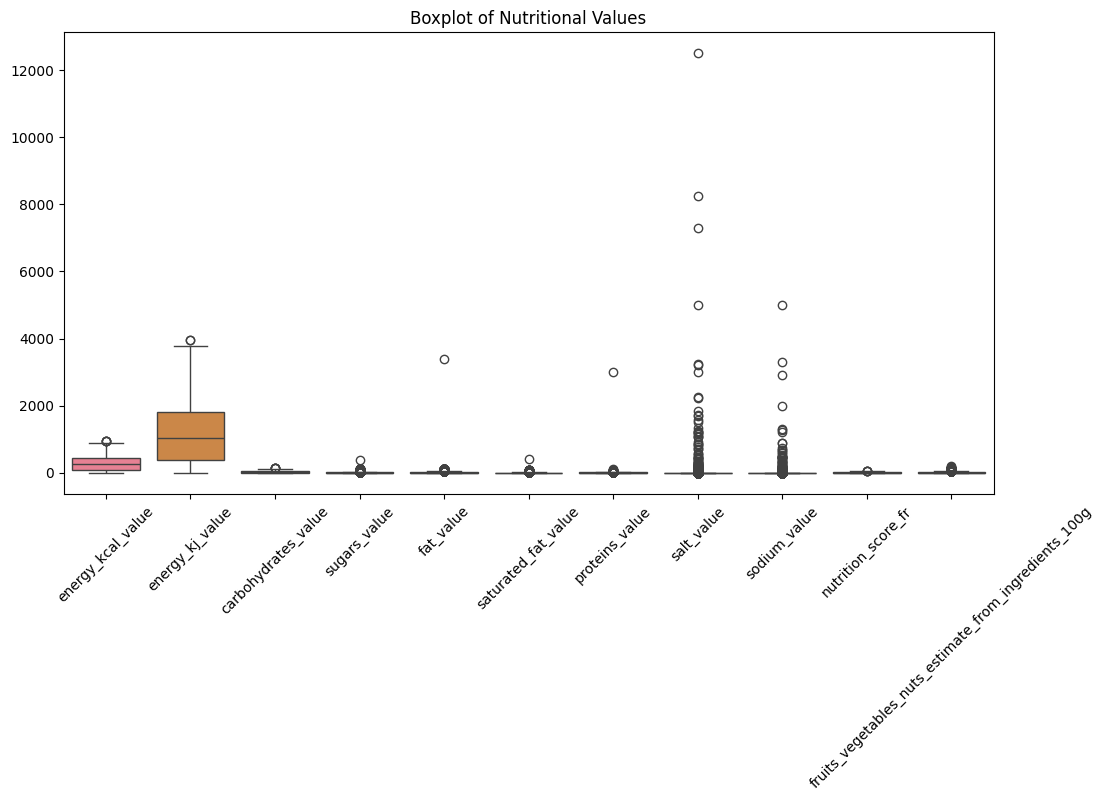

In [7]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[nutrients_columns])
plt.xticks(rotation=45)
plt.title("Boxplot of Nutritional Values")
plt.show()


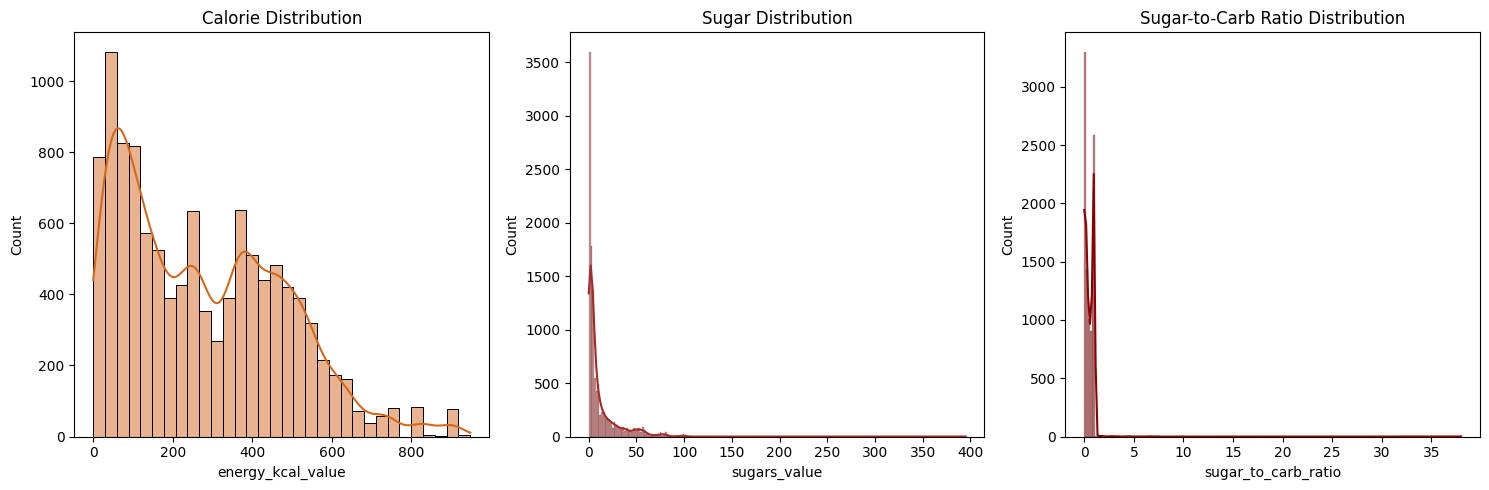

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.histplot(df['energy_kcal_value'], kde=True, ax=axes[0], color='chocolate')
sns.histplot(df['sugars_value'], kde=True, ax=axes[1], color='brown')
sns.histplot(df['sugar_to_carb_ratio'], kde=True, ax=axes[2], color='darkred')
axes[0].set_title("Calorie Distribution")
axes[1].set_title("Sugar Distribution")
axes[2].set_title("Sugar-to-Carb Ratio Distribution")
plt.tight_layout()
plt.show()


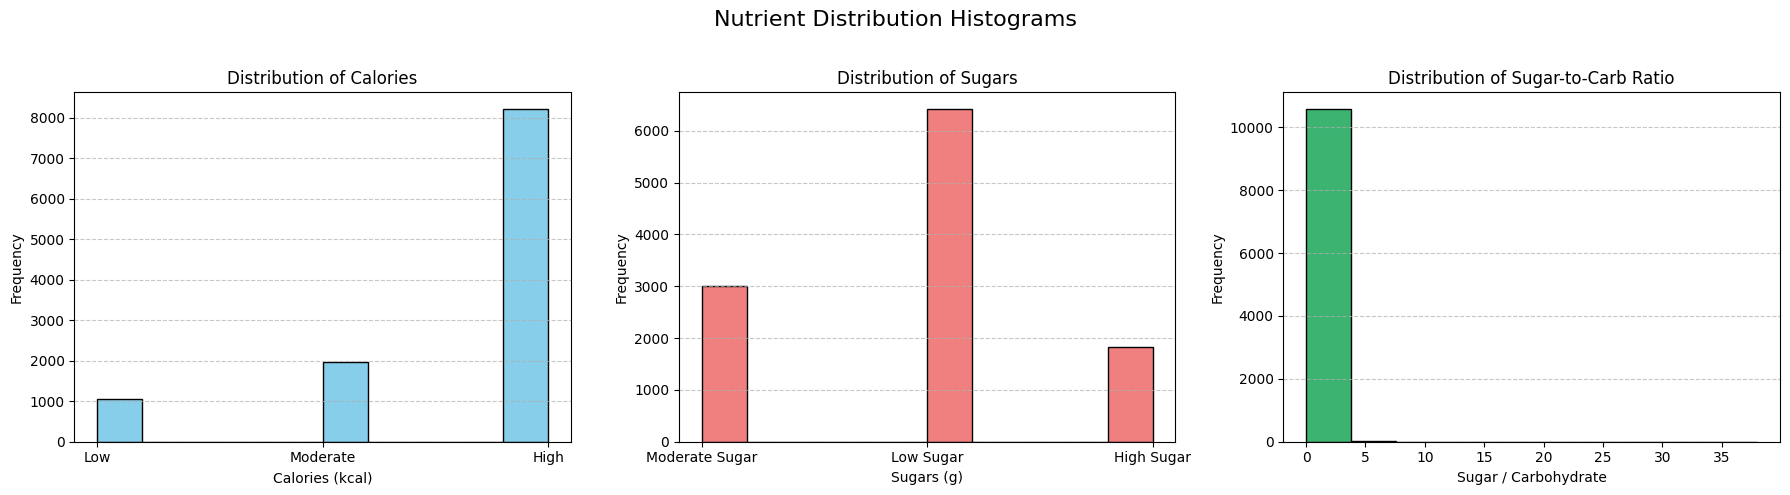

In [14]:
# Set up the plot with multiple subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Nutrient Distribution Histograms', fontsize=16)

# Histogram for Calories
axs[0].hist(df['calorie_category'], bins=10, edgecolor='black', color='skyblue')
axs[0].set_title('Distribution of Calories')
axs[0].set_xlabel('Calories (kcal)')
axs[0].set_ylabel('Frequency')
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

# Histogram for Sugars
axs[1].hist(df['sugar_category'], bins=10, edgecolor='black', color='lightcoral')
axs[1].set_title('Distribution of Sugars')
axs[1].set_xlabel('Sugars (g)')
axs[1].set_ylabel('Frequency')
axs[1].grid(axis='y', linestyle='--', alpha=0.7)

# Histogram for Sugar-to-Carb Ratio
axs[2].hist(df['sugar_to_carb_ratio'], bins=10, edgecolor='black', color='mediumseagreen')
axs[2].set_title('Distribution of Sugar-to-Carb Ratio')
axs[2].set_xlabel('Sugar / Carbohydrate')
axs[2].set_ylabel('Frequency')
axs[2].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent titles from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Display the plot
plt.show()


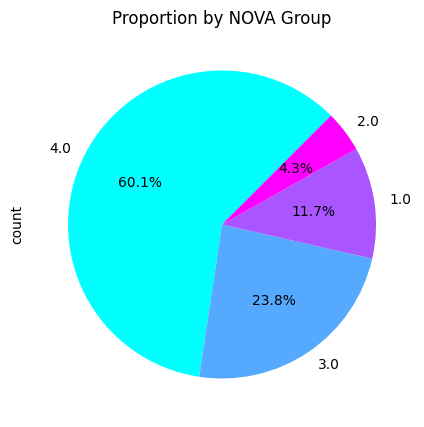

In [10]:
plt.figure(figsize=(8,5))
df['nova_group'].value_counts().plot.pie(autopct='%1.1f%%', startangle=45, cmap='cool')
plt.title("Proportion by NOVA Group")
# plt.ylabel("")
plt.show()

In [ ]:
df=df[df['fat_value']<2500]

Text(0, 0.5, 'Protien Value')

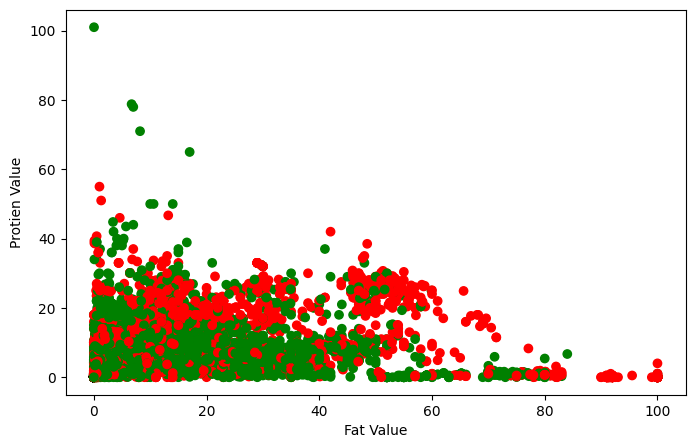

In [30]:
colors = ['green' if group == 'Yes' else 'red' for group in df['is_ultra_processed']]
plt.figure(figsize=(8,5))
plt.scatter(df['fat_value'],df['proteins_value'],c=colors)
plt.xlabel('Fat Value')
plt.ylabel('Protien Value')

Text(0, 0.5, 'Energy Kcal Value')

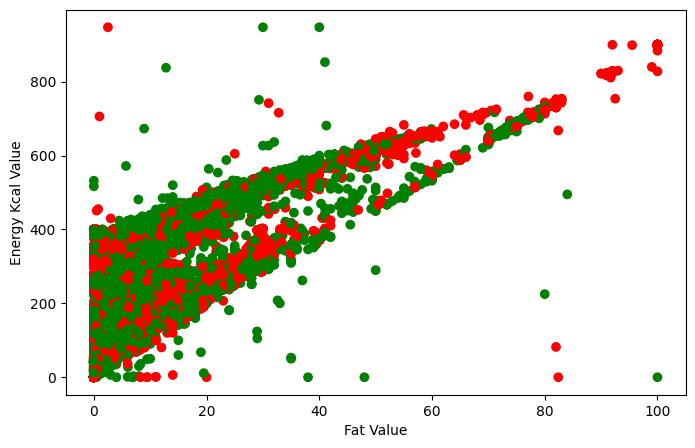

In [36]:
colors = ['green' if group == 'Yes' else 'red' for group in df['is_ultra_processed']]
plt.figure(figsize=(8,5))
plt.scatter(df['fat_value'],df['energy_kcal_value'],c=colors)
plt.xlabel('Fat Value')
plt.ylabel('Energy Kcal Value')

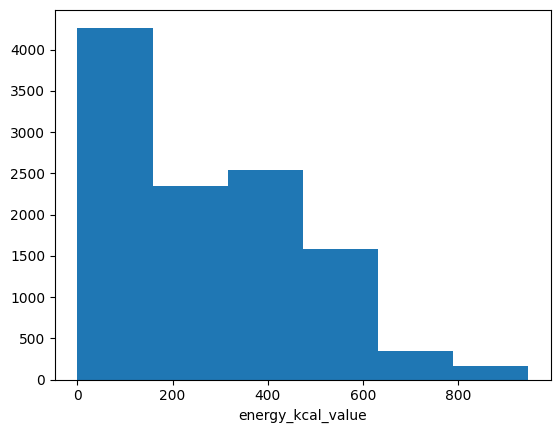

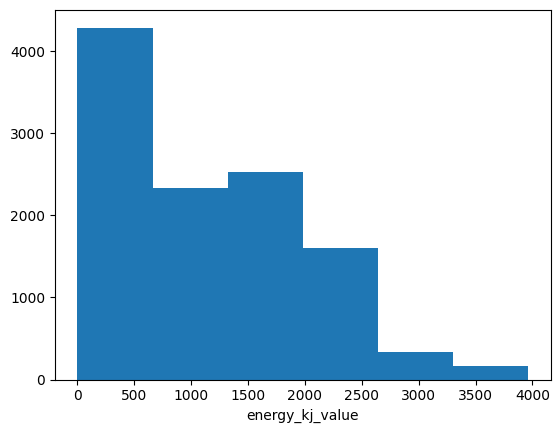

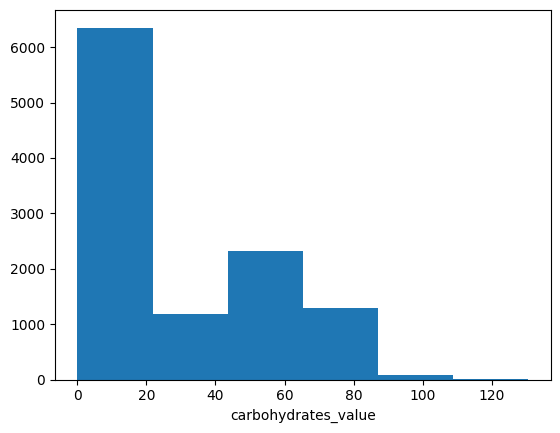

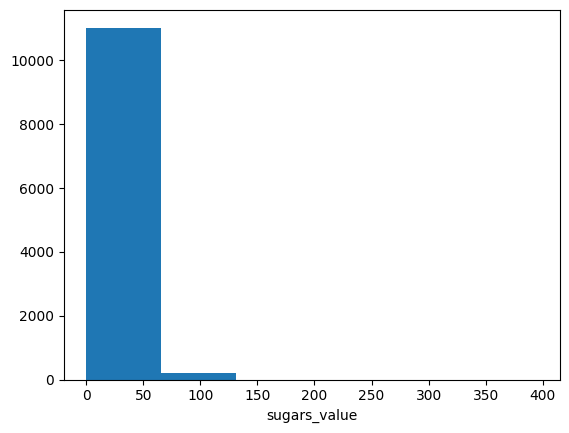

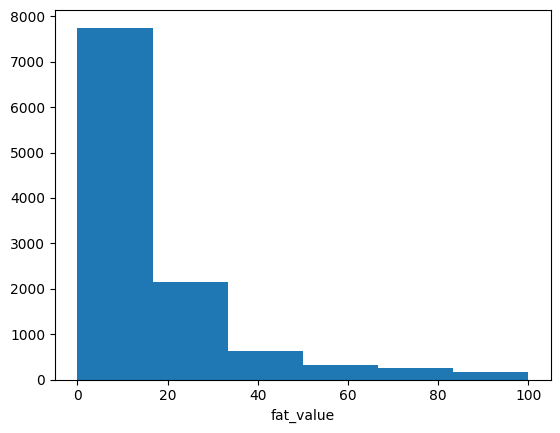

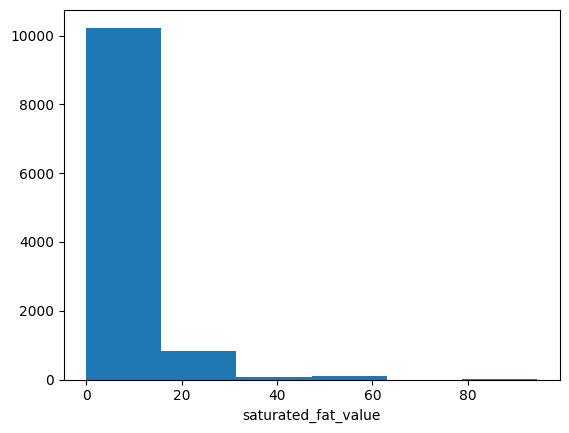

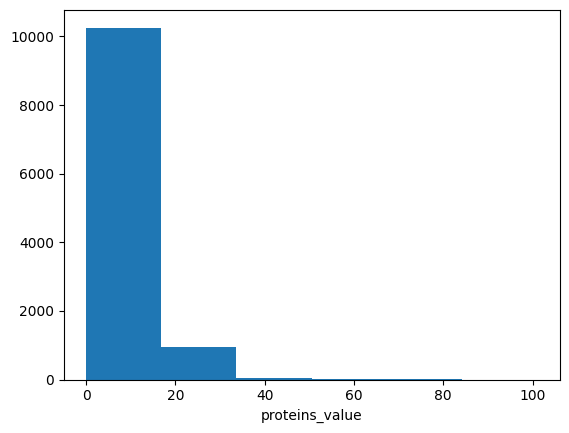

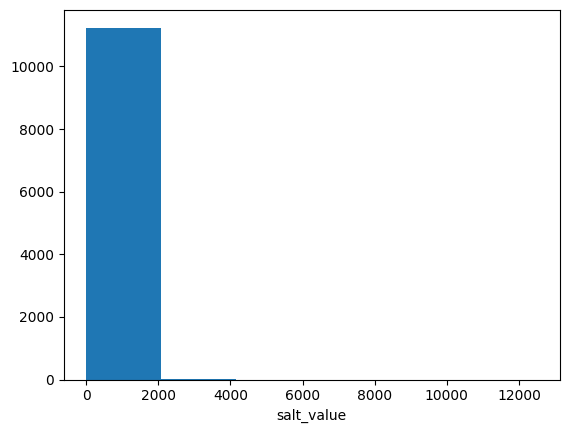

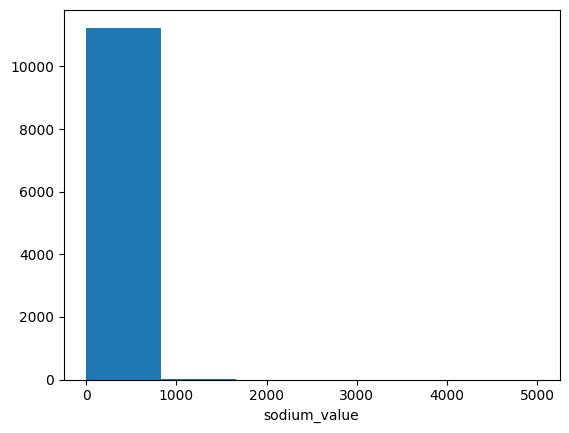

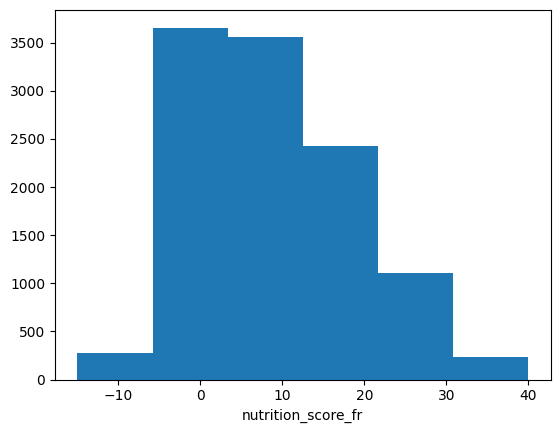

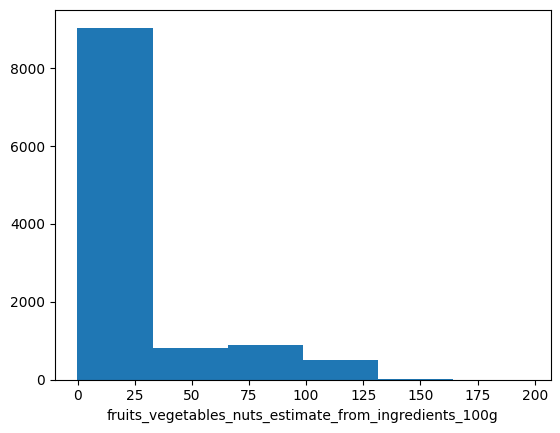

In [46]:
for i in nutrients_columns:
    plt.hist(df[i],bins=6)
    plt.xlabel(f'{i}')
    plt.show()

<Axes: xlabel='count', ylabel='is_ultra_processed'>

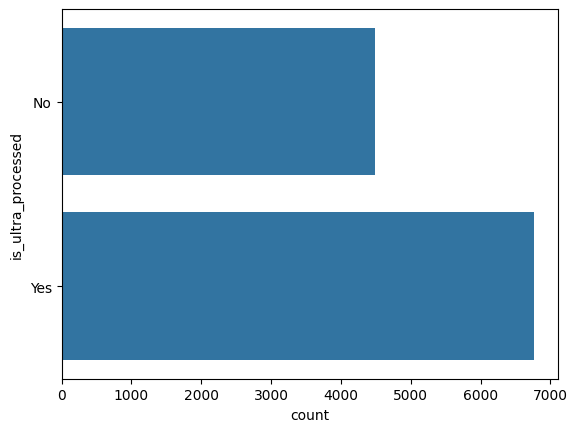

In [42]:
sns.countplot(df['is_ultra_processed'])